In [205]:
#Nötige Bibliotheken importieren
import numpy as np
import matplotlib.pyplot as plt

In [206]:
#Lösen der 1d Poisson-Gleichung: u''(x) = -f(x)

#Zuerst legen wir einige Konstante fest
num_elements = 10#Anzahl an finiten Elementen (ist gleich Anzahl der Knoten - 1)
num_nodes = num_elements + 1#somit ist die Anzahl an Knoten gleich der Anzahl an Elementen + 1
nodes = np.linspace(0, 1, num_nodes)#die Lösung wird ermittelt im Interval [0; 1]
l_per_element = 1 / num_elements#Länge eines finiten Elementes unter der Annahme das alle Elemente gleichlang sind

f_constant = 2#wir arbeiten mit der Annahme das f(x) = f_constant über das Interval [0; 1] ist, diese Variable gibt den Wert von f_constant an

In [207]:
#global Matrix K definieren, diese ist zuerst mit Nullen gefüllt.
#Dies erweist sich als praktisch, da wir die Matrix durch "Addition" der elementweise definieren Matrizen erstellen.
# Alle Stelle der Matrix mit |i - j| > 1 sind somit bereits als 0 eingestellt und müssen nicht manuel geändert werden
K = np.zeros((
    len(nodes), len(nodes)
))

#Dasselbe wird für den globalen Vektor F gemacht
F = np.zeros(len(nodes))

#Diese Variablen wurden erstellt um später das lineare Gleichungsystem Ku=F zu lösen


In [208]:
#Konstruktion der globalen Matrix K und der globalen Vektors F

for i in range(num_elements):
    #K_e stellt die elementweise definierte Matrix K_e dar
    K_e = (1 / l_per_element) * np.array([
        [1, -1],
        [-1, 1]
    ])
    #F_e stellt den elementweise definierten Vektor F_e dar
    F_e = (l_per_element / 2) * np.array([f_constant, f_constant])

    #mithilfe der elementweise definierten Matrix und Vektor werden die globale Matrix und der globale Vektor konstruiert
    K[i:i+2, i:i+2] += K_e
    F[i:i+2] += F_e

In [209]:
#Anwendung der Dirichlet-Randbedingungen
#Für diese Lösung der 1d Poisson-Gleichung sind diese:
#u(0) = 0, u(L) = 1, wobei L die rechte Grenze des Interval ist, also:
#u(0) = 0, u(1) = 1

#fixed_nodes gibt dabei die Indizes der Knoten an den Rändern an
fixed_nodes = [0, -1]#0 => u(0), -1 => u(L) (der Index "-1" kann in Python benutzt werden, um das letzte Element einer Liste zu bekommen)
#fixed_values gibt jeweils die Werte für u(0) und u(L) an
fixed_values = [0, 1]

all_nodes = np.arange(num_nodes)#Indizes aller Knoten
free_nodes = np.delete(all_nodes, fixed_nodes)#Indizes aller "freien" Knoten, dies sind die KNoten welche nicht durch die Randbedingung beschränkt sind

#Die Randbedingungen werden erzwungen, indem der entsprechende Wert an den Rändern von dem globalen Vektor F abgezogen wird.
for i in fixed_nodes:
    F -= K[:, i] * fixed_values[i]

K_free = K[np.ix_(free_nodes, free_nodes)]#stellt die globale Matrix aller "freien" Knoten dar
F_free = F[free_nodes]#stellt den globalen Vektor aller "freien" Knoten dar

In [210]:
#Nun können wir das lineare Gleichungssystem Ku=F nach u lösen
u_free = np.linalg.solve(K_free, F_free)#u_free stellt die Lösung aller freien Knoten dar, die Lösung der restlichen Knoten wurde durch die Randbedingungen gegeben

#Zuletzt kombinieren wir alle freien und restliche Knoten
u = np.zeros(num_nodes)
u[free_nodes] = u_free
u[fixed_nodes] = fixed_values
#u repräsentiert nun den Vektor u, dessen Komponente alle diskreten Werte zur Lösungen der DGL sind

In [211]:
#Ansatzfunktion für das Referenzelement definieren

#In diesem Fall wird eine lineare Ansatzfunktion verwendet
def N0(psi):
    return 0.5 - 0.5 * psi
def N1(psi):
    return 0.5 + 0.5 * psi

In [212]:
#Diese Funktion nimmt einen Wert x ein und gibt dafür den Funktionswert der FEM Lösung aus
#Dabei wird in den Elementen zwischen den Knoten mithilfe der Ansatzfunktion interpoliert
def interpolate_vals(x, nodes, u):
    #Zuerst ermittelt man, in welchem der Elemente sich unser x Wert befindet.
    ind = np.searchsorted(nodes, x) - 1

    ind = np.clip(ind, 0, num_nodes - 2)#zur Sicherheit wird der Index auf einen validen Index beschränkt, wobei unsere funktion nur x innerhalb des Intervals [0;1] erwarten kann

    #node0 gibt den linken Knoten des Elementes an und node1 den rechten Knoten
    node0, node1 = nodes[ind], nodes[ind + 1]#node0 gibt
    #Die Länge des Elementes wird beispielsweise Berechnet, wobei unter vorherigen Annahmen die Länge auch durch Variable "l_per_element" gegeben ist
    l_element = node1 - node0

    #Koordinatentransformation von x zu psi
    #x im Interval [0; L], psi in Interval [-1; 1]
    psi = (2.0 * (x - node0) / l_element) - 1.0

    #Zuletzt wird der Funktionswert durch interpolation mit den Ansatzfunktionen berechnet
    u_value = u[ind] * N0(psi) + u[ind + 1] * N1(psi)
    return u_value

#Diese Funktion dient lediglich der Umgehensweise mit numpy arrays, dabei nimmt die Methode ein Array an x Werten an und liefert ein Array an y Werten
#die vorherige funktion "interpolate_vals" ist jedoch bereits eine vollständige Lösungfunktion für einzelne x Werte
def solution_function_u(x):
    return np.array([interpolate_vals(val, nodes, u) for val in x])


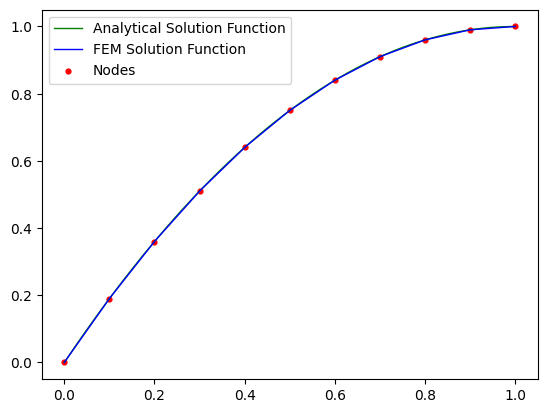

In [214]:
#Analytische Funktion für den Vergleich
def solution_function_u_analytic(x):
    return -f_constant/2 * x * x + (1 + f_constant/2) * x#-f_constant / 2 * x * x + (1 / 1 + f_constant * 1/2) * x

#finally just display this stuff yayyy!!
res = 200#Menge an Punkten die für die Graphen verwendet werden (nicht mit Menge an finiten Elementen zu verwechseln!)

x_axis = np.linspace(0, 1, res)#ein numpy array an x werten im Interval [0; 1]

y_axis_fem = solution_function_u(x_axis)#Die Funktionswerte, welche durch die FEM ermittelt wurden
y_axis_analytic = solution_function_u_analytic(x_axis)#Die Funktionswerte, welche analytisch ermittelt wurden

#zuletzt werden die Daten mit Matplotlib angezeigt
plt.close()#good practice, closes any matplotlib graphcis left behind
plt.plot(x_axis, y_axis_analytic, linewidth=1, label="Analytical Solution Function", c='g')#Zeichnet Graphen der Analytischen Lösung
plt.plot(x_axis, y_axis_fem, linewidth=1, label="FEM Solution Function", c='b')#Zeichnet Graphen der FEM Lösung
plt.scatter(nodes, u, color='red', s=12, label="Nodes")#Zeichnet die Knoten ein, an welchen die diskreten Lösungen errechnet wurden
plt.legend()
plt.show()